
# VRU Borough-Month Severe Collision Prediction

本 notebook 重新按照当前研究思路组织：
- 研究对象为 London VRU（弱势道路使用者，`casualty_type` 为 0 或 1）；
- 建模单元为 `borough-month`；
- 目标变量为每个 borough 在每个月的 `severe_count`（严重事故数，fatal + serious）；
- 特征分为两类：
  - `borough` 固定属性：IMD、road density、junction density、crossing density、speed limit structure；
  - 当月事故环境汇总特征：夜间事故占比、高峰期事故占比、恶劣天气事故占比、湿滑路面事故占比。

数据来源优先使用 GitHub 原始 CSV，便于解释来源；若当前环境离线，则自动回退到本地文件。

说明：
- 由于当前可直接使用的是伤亡与碰撞记录，而不是完整道路网络底图，这里的 `road density / junction density / crossing density` 更准确地说是基于 VRU 事故发生点的空间密度代理（per km²）。
- 这版 notebook 删除了旧的“单条事故严重性分类”流程，改为服务 `borough-month` 月度预测。


In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import smogn
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')


In [2]:
# 1) 数据读取：仅使用 GitHub 线上数据
CASUALTY_URL = 'https://github.com/Taoo2025/CASA0006_DSSS/raw/refs/heads/main/Data/London_casualty.csv'
COLLISION_URL = 'https://github.com/Taoo2025/CASA0006_DSSS/raw/refs/heads/main/London_collision.csv'
VEHICLE_URL = 'https://github.com/Taoo2025/CASA0006_DSSS/raw/refs/heads/main/London_vehicle.csv'
BOROUGH_GPKG_URL = 'https://github.com/Taoo2025/CASA0006_DSSS/raw/refs/heads/main/London_Boroughs.gpkg'



df_casualty = pd.read_csv(CASUALTY_URL, low_memory=False)
df_collision = pd.read_csv(COLLISION_URL, low_memory=False)
df_vehicle = pd.read_csv(VEHICLE_URL, low_memory=False)

print('df_casualty shape:', df_casualty.shape)
print('df_collision shape:', df_collision.shape)
print('df_vehicle shape:', df_vehicle.shape)


df_casualty shape: (120115, 11)
df_collision shape: (104264, 24)
df_vehicle shape: (190964, 6)


In [4]:
# 2.5) 原始数据列检查：如果缺列，会在这里标出来
required_raw_columns = {
    'df_casualty': [
        'collision_index',
        'casualty_type',
        'casualty_imd_decile',
    ],
    'df_collision': [
        'collision_index',
        'longitude',
        'latitude',
        'collision_severity',
        'date',
        'day_of_week',
        'time',
        'local_authority_ons_district',
        'speed_limit',
        'junction_detail',
        'pedestrian_crossing',
        'light_conditions',
        'weather_conditions',
        'road_surface_conditions',
    ],
    'df_vehicle': [
        'collision_index',
        'vehicle_reference',
        'vehicle_type',
    ],
    'borough_gdf': [
        'gss_code',
        'name',
        'hectares',
    ],
}

available_raw_columns = {
    'df_casualty': set(df_casualty.columns),
    'df_collision': set(df_collision.columns),
    'df_vehicle': set(df_vehicle.columns),
    'borough_gdf': set(borough_gdf.columns),
}

raw_column_check = []
for dataset_name, required_cols in required_raw_columns.items():
    missing_cols = sorted(set(required_cols) - available_raw_columns[dataset_name])
    raw_column_check.append({
        'dataset': dataset_name,
        'required_columns': ', '.join(required_cols),
        'missing_columns': ', '.join(missing_cols) if missing_cols else 'NONE',
        'status': 'MISSING' if missing_cols else 'OK',
    })

raw_column_check_df = pd.DataFrame(raw_column_check)
print(raw_column_check_df.to_string(index=False))

if (raw_column_check_df['status'] == 'MISSING').any():
    missing_map = raw_column_check_df.loc[raw_column_check_df['status'] == 'MISSING', ['dataset', 'missing_columns']]
    raise KeyError(f'Missing required raw columns:\n{missing_map.to_string(index=False)}')


     dataset                                                                                                                                                                                                                  required_columns missing_columns status
 df_casualty                                                                                                                                                                               collision_index, casualty_type, casualty_imd_decile            NONE     OK
df_collision collision_index, longitude, latitude, collision_severity, date, day_of_week, time, local_authority_ons_district, speed_limit, junction_detail, pedestrian_crossing, light_conditions, weather_conditions, road_surface_conditions            NONE     OK
  df_vehicle                                                                                                                                                                                  collision_index, vehicle


## Step 1. 提取 VRU 事故

根据 DfT 说明，`casualty_type`：
- `0` = Pedestrian
- `1` = Cyclist

因此这里将所有涉及 pedestrian 或 cyclist casualty 的 collision 视为 VRU collision。


In [12]:

# 3) 提取 VRU casualty，并匹配出对应 collision
for frame in [df_casualty, df_collision, df_vehicle]:
    frame['collision_index'] = frame['collision_index'].astype(str).str.strip()

for col in ['casualty_type', 'casualty_imd_decile']:
    df_casualty[col] = pd.to_numeric(df_casualty[col], errors='coerce')

vru_casualty = df_casualty[df_casualty['casualty_type'].isin([0, 1])].copy()
vru_collision_ids = set(vru_casualty['collision_index'].unique())

vru_collision = df_collision[df_collision['collision_index'].isin(vru_collision_ids)].copy()
vru_vehicle = df_vehicle[df_vehicle['collision_index'].isin(vru_collision_ids)].copy()

print('VRU casualty rows:', len(vru_casualty))
print('VRU collision rows:', len(vru_collision))
print('VRU vehicle rows:', len(vru_vehicle))
print(vru_casualty['casualty_type'].value_counts(dropna=False).sort_index())


VRU casualty rows: 42647
VRU collision rows: 41563
VRU vehicle rows: 65288
casualty_type
0    19603
1    23044
Name: count, dtype: int64


In [ ]:

# 4) 字段清洗与时间变量构造
vru_collision = vru_collision[vru_collision['borough_code'].isin(borough_meta['borough_code'])].copy()

vru_collision['date'] = pd.to_datetime(vru_collision['date'], dayfirst=True, errors='coerce')
vru_collision['time_dt'] = pd.to_datetime(vru_collision['time'], format='%H:%M', errors='coerce')
vru_collision['month'] = vru_collision['date'].dt.to_period('M').dt.to_timestamp()

num_cols = [
    'collision_severity', 'day_of_week', 'speed_limit', 'junction_detail', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions', 'longitude', 'latitude'
]
for col in num_cols:
    vru_collision[col] = pd.to_numeric(vru_collision[col], errors='coerce')

vru_collision['is_severe'] = vru_collision['collision_severity'].isin([1, 2]).astype(int)

# 工作日高峰：Mon-Fri 06:30-09:30 和 16:00-19:00
weekday_mask = vru_collision['day_of_week'].isin([2, 3, 4, 5, 6])
morning_peak = (
    ((vru_collision['time_dt'].dt.hour > 6) | ((vru_collision['time_dt'].dt.hour == 6) & (vru_collision['time_dt'].dt.minute >= 30)))
    & ((vru_collision['time_dt'].dt.hour < 9) | ((vru_collision['time_dt'].dt.hour == 9) & (vru_collision['time_dt'].dt.minute <= 30)))
)
evening_peak = (
    (vru_collision['time_dt'].dt.hour >= 16)
    & ((vru_collision['time_dt'].dt.hour < 19) | ((vru_collision['time_dt'].dt.hour == 19) & (vru_collision['time_dt'].dt.minute == 0)))
)
vru_collision['peak_hour_flag'] = np.where(
    vru_collision['time_dt'].notna(),
    (weekday_mask & (morning_peak | evening_peak)).astype(float),
    np.nan,
)

# 夜间：优先使用时间，若缺时间则用 light_conditions 中的 darkness 类别补充
vru_collision['night_flag'] = np.where(
    vru_collision['time_dt'].notna(),
    ((vru_collision['time_dt'].dt.hour >= 19) | (vru_collision['time_dt'].dt.hour < 6)).astype(float),
    np.where(vru_collision['light_conditions'].isin([4, 5, 6, 7]), 1.0, np.where(vru_collision['light_conditions'] == 1, 0.0, np.nan)),
)

# 恶劣天气：raining / snowing / high winds / fog-mist / other
vru_collision['adverse_weather_flag'] = np.where(
    vru_collision['weather_conditions'].isin([2, 3, 4, 5, 6, 7, 8]),
    1.0,
    np.where(vru_collision['weather_conditions'] == 1, 0.0, np.nan),
)

# 湿滑路面：wet-damp / snow / frost-ice / flood / oil-diesel / mud
vru_collision['slippery_surface_flag'] = np.where(
    vru_collision['road_surface_conditions'].isin([2, 3, 4, 5, 6, 7]),
    1.0,
    np.where(vru_collision['road_surface_conditions'] == 1, 0.0, np.nan),
)

# 构造事故点代理：将经纬度四舍五入到 4 位小数，近似表示同一空间位置
vru_collision['site_key'] = (
    vru_collision['longitude'].round(4).astype(str) + '_' + vru_collision['latitude'].round(4).astype(str)
)
vru_collision.loc[vru_collision['longitude'].isna() | vru_collision['latitude'].isna(), 'site_key'] = np.nan

vru_collision = vru_collision.merge(borough_meta, on='borough_code', how='left')

vru_collision[['collision_index', 'borough', 'month', 'is_severe', 'peak_hour_flag', 'night_flag']].head()


,collision_index,borough,month,is_severe,peak_hour_flag,night_flag
0,2023481355197,City of London,2023-01-01,0,1.0,0.0
1,2024010527690,Barking and Dagenham,2024-08-01,1,0.0,0.0
2,2023010455925,Barnet,2023-07-01,0,0.0,0.0
3,2021010349037,Bexley,2021-12-01,0,0.0,0.0
4,2023010422173,Bexley,2023-01-01,0,0.0,1.0



## Step 2. 计算 borough 固定属性

这里的固定属性在整个研究期内不随月份变化：
- `imd_mean`：该 borough 内 VRU casualty 的平均 IMD decile；
- `road_density`：该 borough 内 unique VRU collision site / km²；
- `junction_density`：`junction_detail != 0` 的 unique VRU collision site / km²；
- `crossing_density`：存在 physical crossing facility 的 unique VRU collision site / km²；
- `speed_limit_share_*`：该 borough 内 VRU collision 对应不同 `speed_limit` 的结构占比。


In [7]:

# 5) borough 固定属性
vru_casualty_borough = vru_casualty.merge(
    vru_collision[['collision_index', 'borough_code']].drop_duplicates(),
    on='collision_index',
    how='left'
)

imd_by_borough = (
    vru_casualty_borough
    .query('casualty_imd_decile >= 1 and casualty_imd_decile <= 10')
    .groupby('borough_code', as_index=False)['casualty_imd_decile']
    .mean()
    .rename(columns={'casualty_imd_decile': 'imd_mean'})
)

site_base = vru_collision.dropna(subset=['site_key']).drop_duplicates(['borough_code', 'site_key']).copy()
area_map = borough_meta.set_index('borough_code')['area_km2']

road_density = (
    site_base.groupby('borough_code')['site_key']
    .nunique()
    .div(area_map, fill_value=np.nan)
    .rename('road_density')
    .reset_index()
)

junction_density = (
    site_base[site_base['junction_detail'].isin([13, 16, 17, 18, 19])]
    .groupby('borough_code')['site_key']
    .nunique()
    .div(area_map, fill_value=np.nan)
    .rename('junction_density')
    .reset_index()
)

crossing_density = (
    site_base[site_base['pedestrian_crossing'].isin([11, 12, 13, 14, 15, 16, 17])]
    .groupby('borough_code')['site_key']
    .nunique()
    .div(area_map, fill_value=np.nan)
    .rename('crossing_density')
    .reset_index()
)

speed_counts = (
    vru_collision[vru_collision['speed_limit'].isin([20, 30, 40, 50, 60, 70])]
    .groupby(['borough_code', 'speed_limit'], as_index=False)
    .size()
    .rename(columns={'size': 'n'})
)
speed_counts['share'] = speed_counts['n'] / speed_counts.groupby('borough_code')['n'].transform('sum')
speed_structure = (
    speed_counts
    .pivot(index='borough_code', columns='speed_limit', values='share')
    .reindex(columns=[20, 30, 40, 50, 60, 70], fill_value=0)
    .rename(columns=lambda x: f'speed_limit_share_{int(x)}')
    .reset_index()
)

borough_fixed = borough_meta.copy()
for part in [imd_by_borough, road_density, junction_density, crossing_density, speed_structure]:
    borough_fixed = borough_fixed.merge(part, on='borough_code', how='left')

speed_cols = [c for c in borough_fixed.columns if c.startswith('speed_limit_share_')]
borough_fixed[speed_cols] = borough_fixed[speed_cols].fillna(0)
borough_fixed.head()


,borough_code,borough,area_km2,imd_mean,road_density,junction_density,crossing_density,speed_limit_share_20,speed_limit_share_30,speed_limit_share_40,speed_limit_share_50,speed_limit_share_60,speed_limit_share_70
0,E09000001,City of London,3.14942,4.900826,147.646233,91.445409,95.890672,0.987500,0.012500,0.000000,0.000000,0.000000,0.000000
1,E09000002,Barking and Dagenham,37.79934,2.923729,15.317728,8.730311,6.719694,0.152709,0.825944,0.011494,0.008210,0.001642,0.000000
2,E09000003,Barnet,86.74837,5.462488,12.115501,7.827236,4.749369,0.158416,0.794779,0.027003,0.015302,0.000900,0.003600
3,E09000004,Bexley,64.28649,5.583474,9.286555,4.759943,3.328849,0.178862,0.780488,0.030894,0.008130,0.001626,0.000000
4,E09000005,Brent,43.23270,3.846966,26.715889,16.214578,12.513676,0.309465,0.667490,0.019753,0.002469,0.000000,0.000823



## Step 3. 聚合 borough-month 月度面板

月度环境汇总特征全部从该 borough 当月 VRU collision 记录计算：
- `night_collision_share`
- `peak_hour_collision_share`
- `adverse_weather_collision_share`
- `slippery_surface_collision_share`

目标变量：
- `severe_count` = 每月 fatal + serious collision 数量
- `severe_rate` = 每月严重事故数 / 每月总事故数

这两个目标分别回答不同问题：
- `severe_count` 更适合资源投放与工作量预估；
- `severe_rate` 更适合在控制交通总量影响后，识别相对更危险的 borough-month。


In [8]:

# 6) borough-month 面板

def mean_or_nan(s):
    s = s.dropna()
    return np.nan if s.empty else float(s.mean())

borough_month = (
    vru_collision.dropna(subset=['month'])
    .groupby(['borough_code', 'month'], as_index=False)
    .agg(
        collision_count=('collision_index', 'size'),
        severe_count=('is_severe', 'sum'),
        night_collision_share=('night_flag', mean_or_nan),
        peak_hour_collision_share=('peak_hour_flag', mean_or_nan),
        adverse_weather_collision_share=('adverse_weather_flag', mean_or_nan),
        slippery_surface_collision_share=('slippery_surface_flag', mean_or_nan),
    )
)
borough_month['severe_rate'] = np.where(
    borough_month['collision_count'] > 0,
    borough_month['severe_count'] / borough_month['collision_count'],
    np.nan,
)

# 为每个 borough 补齐完整月份，避免后续滞后特征错位
all_months = pd.date_range(borough_month['month'].min(), borough_month['month'].max(), freq='MS')
all_boroughs = borough_fixed['borough_code'].sort_values().tolist()
full_index = pd.MultiIndex.from_product([all_boroughs, all_months], names=['borough_code', 'month'])

borough_month = (
    borough_month
    .set_index(['borough_code', 'month'])
    .reindex(full_index)
    .reset_index()
)
borough_month[['collision_count', 'severe_count']] = borough_month[['collision_count', 'severe_count']].fillna(0)
borough_month[['collision_count', 'severe_count']] = borough_month[['collision_count', 'severe_count']].astype(int)
borough_month['severe_rate'] = np.where(
    borough_month['collision_count'] > 0,
    borough_month['severe_count'] / borough_month['collision_count'],
    np.nan,
)

panel_df = borough_month.merge(borough_fixed, on='borough_code', how='left')
panel_df = panel_df.sort_values(['borough_code', 'month']).reset_index(drop=True)

print('Panel rows:', len(panel_df))
print('Boroughs:', panel_df['borough_code'].nunique())
print('Months:', panel_df['month'].nunique())
panel_df.head()


Panel rows: 1980
Boroughs: 33
Months: 60


,borough_code,month,collision_count,severe_count,night_collision_share,peak_hour_collision_share,adverse_weather_collision_share,slippery_surface_collision_share,severe_rate,borough,area_km2,imd_mean,road_density,junction_density,crossing_density,speed_limit_share_20,speed_limit_share_30,speed_limit_share_40,speed_limit_share_50,speed_limit_share_60,speed_limit_share_70
0,E09000001,2020-01-01,10,5,0.400000,0.400000,0.000000,0.100000,0.500000,City of London,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0
1,E09000001,2020-02-01,12,5,0.000000,0.750000,0.166667,0.250000,0.416667,City of London,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0
2,E09000001,2020-03-01,3,1,0.666667,0.333333,0.333333,0.666667,0.333333,City of London,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0
3,E09000001,2020-04-01,3,0,0.000000,0.666667,0.000000,0.000000,0.000000,City of London,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0
4,E09000001,2020-05-01,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,City of London,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0


In [40]:
# 7) 简单检查
print('Zero-collision borough-month rows:', int((panel_df['collision_count'] == 0).sum()))
print('\nMissing values:')
print(panel_df.isna().sum().sort_values(ascending=False).head(15))


Zero-collision borough-month rows: 3

Missing values:
night_collision_share               3
severe_rate                         3
slippery_surface_collision_share    3
adverse_weather_collision_share     3
peak_hour_collision_share           3
severe_count                        0
collision_count                     0
month                               0
borough_code                        0
borough                             0
area_km2                            0
imd_mean                            0
road_density                        0
junction_density                    0
crossing_density                    0
dtype: int64



## Step 4. 构造机器学习特征

这里采用面板预测最常见的两类输入：
- 当前月结构与环境特征；
- 每个 borough 自身的历史滞后特征。

为了避免信息泄漏，所有滞后和滚动统计都只使用历史月份。


In [9]:
# 8) 构造滞后与滚动特征 [MODIFIED: 方案A - 移除lag_12，使用forward fill填充初期NaN]
model_df = panel_df.copy().sort_values(['borough_code', 'month']).reset_index(drop=True)

# 只构造 lag_1, 2, 3, 6（移除 lag_12 以避免大量初期 NaN）
for lag in [1, 2, 3, 6]:
    model_df[f'lag_{lag}_severe_count'] = model_df.groupby('borough_code')['severe_count'].shift(lag)
    model_df[f'lag_{lag}_collision_count'] = model_df.groupby('borough_code')['collision_count'].shift(lag)
    model_df[f'lag_{lag}_severe_rate'] = model_df.groupby('borough_code')['severe_rate'].shift(lag)

# 使用 forward fill 补充初期的 NaN（每个 borough 内）
for col in [c for c in model_df.columns if c.startswith('lag_')]:
    model_df[col] = model_df.groupby('borough_code')[col].fillna(method='ffill').fillna(method='bfill')

# 月度环境变量在预测当月通常不可直接获得，因此只保留其滞后值。
for col in [
    'night_collision_share',
    'peak_hour_collision_share',
    'adverse_weather_collision_share',
    'slippery_surface_collision_share',
]:
    model_df[f'lag_1_{col}'] = model_df.groupby('borough_code')[col].shift(1)
    # 对环境特征的滞后值也进行 forward fill
    model_df[f'lag_1_{col}'] = model_df.groupby('borough_code')[f'lag_1_{col}'].fillna(method='ffill').fillna(method='bfill')

model_df['roll3_mean_severe_count'] = (
    model_df.groupby('borough_code')['severe_count'].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
)
model_df['roll6_mean_severe_count'] = (
    model_df.groupby('borough_code')['severe_count'].shift(1).rolling(6).mean().reset_index(level=0, drop=True)
)
model_df['roll3_mean_collision_count'] = (
    model_df.groupby('borough_code')['collision_count'].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
)
model_df['roll6_mean_collision_count'] = (
    model_df.groupby('borough_code')['collision_count'].shift(1).rolling(6).mean().reset_index(level=0, drop=True)
)

# 对滚动特征也进行 forward fill
for col in ['roll3_mean_severe_count', 'roll6_mean_severe_count', 'roll3_mean_collision_count', 'roll6_mean_collision_count']:
    model_df[col] = model_df.groupby('borough_code')[col].fillna(method='ffill').fillna(method='bfill')

model_df['month_num'] = model_df['month'].dt.month
model_df['year_num'] = model_df['month'].dt.year
model_df['month_sin'] = np.sin(2 * np.pi * model_df['month_num'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['month_num'] / 12)

model_df = pd.get_dummies(model_df, columns=['borough'], drop_first=True)

# 改进的 NaN 处理：使用 SimpleImputer 而不是简单的 dropna()
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
lag_cols = [c for c in model_df.columns if c.startswith('lag_') or c.startswith('roll')]
model_df[lag_cols] = imputer.fit_transform(model_df[lag_cols])
model_df['severe_rate'] = model_df['severe_rate'].fillna(model_df['severe_rate'].median())

model_df = model_df.reset_index(drop=True)

print('Model rows after lag feature construction (with fill):', len(model_df))
print('\nMissing values after imputation:')
print(model_df.isna().sum().sum(), 'total missing values')
model_df.head()


Model rows after lag feature construction (with fill): 1980

Missing values after imputation:
12 total missing values


,borough_code,month,collision_count,severe_count,night_collision_share,peak_hour_collision_share,adverse_weather_collision_share,slippery_surface_collision_share,severe_rate,area_km2,imd_mean,road_density,junction_density,crossing_density,speed_limit_share_20,speed_limit_share_30,speed_limit_share_40,speed_limit_share_50,speed_limit_share_60,speed_limit_share_70,lag_1_severe_count,lag_1_collision_count,lag_1_severe_rate,lag_2_severe_count,lag_2_collision_count,lag_2_severe_rate,lag_3_severe_count,lag_3_collision_count,lag_3_severe_rate,lag_6_severe_count,lag_6_collision_count,lag_6_severe_rate,lag_1_night_collision_share,lag_1_peak_hour_collision_share,lag_1_adverse_weather_collision_share,lag_1_slippery_surface_collision_share,roll3_mean_severe_count,roll6_mean_severe_count,roll3_mean_collision_count,roll6_mean_collision_count,month_num,year_num,month_sin,month_cos,borough_Barnet,borough_Bexley,borough_Brent,borough_Bromley,borough_Camden,borough_City of London,borough_Croydon,borough_Ealing,borough_Enfield,borough_Greenwich,borough_Hackney,borough_Hammersmith and Fulham,borough_Haringey,borough_Harrow,borough_Havering,borough_Hillingdon,borough_Hounslow,borough_Islington,borough_Kensington and Chelsea,borough_Kingston upon Thames,borough_Lambeth,borough_Lewisham,borough_Merton,borough_Newham,borough_Redbridge,borough_Richmond upon Thames,borough_Southwark,borough_Sutton,borough_Tower Hamlets,borough_Waltham Forest,borough_Wandsworth,borough_Westminster
0,E09000001,2020-01-01,10,5,0.400000,0.400000,0.000000,0.100000,0.500000,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0,5.0,10.0,0.500000,5.0,10.0,0.500000,5.0,10.0,0.500000,5.0,10.0,0.5,0.400000,0.400000,0.000000,0.100000,3.666667,1.833333,8.333333,5.0,1,2020,0.500000,8.660254e-01,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,E09000001,2020-02-01,12,5,0.000000,0.750000,0.166667,0.250000,0.416667,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0,5.0,10.0,0.500000,5.0,10.0,0.500000,5.0,10.0,0.500000,5.0,10.0,0.5,0.400000,0.400000,0.000000,0.100000,3.666667,1.833333,8.333333,5.0,2,2020,0.866025,5.000000e-01,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,E09000001,2020-03-01,3,1,0.666667,0.333333,0.333333,0.666667,0.333333,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0,5.0,12.0,0.416667,5.0,10.0,0.500000,5.0,10.0,0.500000,5.0,10.0,0.5,0.000000,0.750000,0.166667,0.250000,3.666667,1.833333,8.333333,5.0,3,2020,1.000000,6.123234e-17,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,E09000001,2020-04-01,3,0,0.000000,0.666667,0.000000,0.000000,0.000000,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0,1.0,3.0,0.333333,5.0,12.0,0.416667,5.0,10.0,0.500000,5.0,10.0,0.5,0.666667,0.333333,0.333333,0.666667,3.666667,1.833333,8.333333,5.0,4,2020,0.866025,-5.000000e-01,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,E09000001,2020-05-01,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,3.14942,4.900826,147.646233,91.445409,95.890672,0.9875,0.0125,0.0,0.0,0.0,0.0,0.0,3.0,0.000000,1.0,3.0,0.333333,5.0,12.0,0.416667,5.0,10.0,0.5,0.000000,0.666667,0.000000,0.000000,2.000000,1.833333,6.000000,5.0,5,2020,0.500000,-8.660254e-01,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Step 5. 时间序列验证、随机森林、XGBoost 与 SHAP 对比

这一部分综合了课程中几周最适合当前任务的方法：
- week2：回归指标评估（MAE / RMSE / R2）
- week3：`TimeSeriesSplit` 与 `GridSearchCV`
- week4：树模型与 `XGBoost`
- week7：特征重要性、`SHAP`
- week10：加入基础的无泄漏检查和输入一致性检查


In [10]:
# 9) 时间切分、特征检查、以及按年份滚动扩张窗口的 backtesting
model_df_time = model_df.sort_values(['month', 'borough_code']).reset_index(drop=True)
borough_col = 'borough'
available_years = sorted(model_df_time['year_num'].unique().tolist())
smogn_years = [year for year in available_years if 2020 <= year <= 2023]

if len(available_years) < 3:
    raise ValueError(f'Need at least 3 years for rolling-origin evaluation, but only found: {available_years}')

rolling_year_folds = []
for i in range(1, len(available_years)):
    train_years = available_years[:i]
    test_year = available_years[i]
    rolling_year_folds.append({
        'fold_label': f"{train_years[0]}-{train_years[-1]} -> {test_year}" if len(train_years) > 1 else f"{train_years[0]} -> {test_year}",
        'train_years': train_years,
        'test_year': test_year,
        'is_final_test': i == len(available_years) - 1,
    })

final_fold = rolling_year_folds[-1]
train_years_final = final_fold['train_years']
test_year_final = final_fold['test_year']

train_df = model_df_time[model_df_time['year_num'].isin(train_years_final)].copy()
test_df = model_df_time[model_df_time['year_num'] == test_year_final].copy()


def evaluate_regression_model(model_name, y_true, y_pred, fit_seconds):
    return {
        'model': model_name,
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
        'fit_seconds': fit_seconds,
    }


def clip_predictions(task_name, values):
    if task_name == 'count':
        return np.clip(values, 0, None)
    if task_name == 'rate':
        return np.clip(values, 0, 1)
    raise ValueError(f'Unknown task: {task_name}')


def smogn_resample_training_years(X, y, year_series, task_name, random_state=42):
    X_df = pd.DataFrame(X).reset_index(drop=True).copy()
    y_series = pd.Series(y).reset_index(drop=True).copy()
    year_series = pd.Series(year_series).reset_index(drop=True).copy()
    eligible_mask = year_series.isin(smogn_years)

    X_eligible = X_df.loc[eligible_mask].reset_index(drop=True)
    y_eligible = y_series.loc[eligible_mask].reset_index(drop=True)
    X_other = X_df.loc[~eligible_mask].reset_index(drop=True)
    y_other = y_series.loc[~eligible_mask].reset_index(drop=True)

    if X_eligible.empty or len(X_eligible) < 10 or y_eligible.nunique() < 2:
        summary_df = pd.DataFrame([{
            'year_scope': '2020-2023',
            'original_n': int(len(X_eligible)),
            'resampled_n': int(len(X_eligible)),
            'delta_n': 0,
            'method': 'smogn_skipped',
        }])
        return X_df, y_series, summary_df

    train_smogn_df = X_eligible.copy()
    train_smogn_df['target'] = y_eligible.values

    np.random.seed(random_state)
    try:
        smogn_df = smogn.smoter(
            data=train_smogn_df,
            y='target',
            k=min(5, max(3, len(train_smogn_df) - 1)),
            pert=0.02,
            samp_method='balance',
            under_samp=True,
            drop_na_col=False,
            drop_na_row=False,
            replace=False,
            rel_thres=0.5,
            rel_method='auto',
            rel_xtrm_type='both',
            rel_coef=1.5,
        )
        X_eligible_resampled = smogn_df.drop(columns=['target']).reset_index(drop=True)
        X_eligible_resampled = X_eligible_resampled[X_eligible.columns]
        for col in X_eligible.columns:
            X_eligible_resampled[col] = pd.to_numeric(X_eligible_resampled[col], errors='coerce')
            if str(X_eligible[col].dtype).startswith('int'):
                X_eligible_resampled[col] = X_eligible_resampled[col].round().astype(int)
            else:
                X_eligible_resampled[col] = X_eligible_resampled[col].astype(float)
        y_eligible_resampled = pd.to_numeric(smogn_df['target'].reset_index(drop=True), errors='coerce')
        if task_name == 'rate':
            y_eligible_resampled = y_eligible_resampled.clip(0, 1).astype(float)
        else:
            y_eligible_resampled = y_eligible_resampled.clip(lower=0).astype(float)
        method = 'smogn_package'
    except Exception:
        X_eligible_resampled = X_eligible.copy()
        y_eligible_resampled = y_eligible.copy()
        method = 'smogn_fallback_original'

    X_other = X_other[X_eligible.columns].copy()
    for col in X_other.columns:
        X_other[col] = pd.to_numeric(X_other[col], errors='coerce')
        if str(X_eligible[col].dtype).startswith('int'):
            X_other[col] = X_other[col].round().astype(int)
        else:
            X_other[col] = X_other[col].astype(float)
    y_other = pd.to_numeric(y_other, errors='coerce').astype(float)
    X_resampled = pd.concat([X_other, X_eligible_resampled], ignore_index=True)
    y_resampled = pd.concat([y_other, y_eligible_resampled], ignore_index=True)
    X_resampled = X_resampled.apply(pd.to_numeric, errors='coerce')
    summary_df = pd.DataFrame([{
        'year_scope': '2020-2023',
        'original_n': int(len(X_eligible)),
        'resampled_n': int(len(X_eligible_resampled)),
        'delta_n': int(len(X_eligible_resampled) - len(X_eligible)),
        'method': method,
    }])
    return X_resampled, y_resampled, summary_df


def fit_model_by_name(model_name, params=None, task_name=None):
    params = params or {}
    if model_name == 'LinearRegression_baseline':
        return LinearRegression()
    if model_name == 'RandomForest_baseline':
        return RandomForestRegressor(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
    if model_name == 'RandomForest_tuned':
        return RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params,
        )
    if model_name == 'XGBoost':
        xgb_objective = 'count:poisson' if task_name == 'count' else 'reg:squarederror'
        xgb_eval_metric = 'poisson-nloglik' if task_name == 'count' else 'rmse'
        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            objective=xgb_objective,
            eval_metric=xgb_eval_metric,
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
        )
    raise ValueError(f'Unsupported model name: {model_name}')


def time_series_grid_search_with_train_smogn(task_name, dataset, param_grid, random_state=42):
    cv_rows = []
    best_score = np.inf
    best_params = None
    train_years_sorted = sorted(dataset['train_df']['year_num'].unique().tolist())

    for params in ParameterGrid(param_grid):
        fold_rmses = []
        for fold_id, cutoff in enumerate(range(1, len(train_years_sorted)), start=1):
            fold_train_years = train_years_sorted[:cutoff]
            fold_valid_year = train_years_sorted[cutoff]
            fold_train_df = dataset['train_df'][dataset['train_df']['year_num'].isin(fold_train_years)].copy()
            fold_valid_df = dataset['train_df'][dataset['train_df']['year_num'] == fold_valid_year].copy()

            X_fold_train = fold_train_df[dataset['feature_cols']].copy()
            y_fold_train = fold_train_df[dataset['target_col']].copy()
            year_fold_train = fold_train_df['year_num'].copy()
            X_fold_valid = fold_valid_df[dataset['feature_cols']].copy()
            y_fold_valid = fold_valid_df[dataset['target_col']].copy()

            X_fold_train_smogn, y_fold_train_smogn, _ = smogn_resample_training_years(
                X_fold_train,
                y_fold_train,
                year_fold_train,
                task_name=task_name,
                random_state=random_state + fold_id,
            )

            model = fit_model_by_name('RandomForest_tuned', params=params)
            model.fit(X_fold_train_smogn, y_fold_train_smogn)
            pred = clip_predictions(task_name, model.predict(X_fold_valid))
            fold_rmses.append(float(np.sqrt(mean_squared_error(y_fold_valid, pred))))

        mean_rmse = float(np.mean(fold_rmses))
        std_rmse = float(np.std(fold_rmses))
        cv_rows.append({
            'params': params,
            'mean_test_score': -mean_rmse,
            'std_test_score': std_rmse,
            'rank_proxy_rmse': mean_rmse,
        })
        if mean_rmse < best_score:
            best_score = mean_rmse
            best_params = params

    cv_df = pd.DataFrame(cv_rows).sort_values(['rank_proxy_rmse', 'std_test_score']).reset_index(drop=True)
    cv_df['rank_test_score'] = np.arange(1, len(cv_df) + 1)
    return best_params, cv_df


def run_expanding_window_backtest(task_name, dataset, model_name, params=None, use_smogn=True):
    rows = []
    for fold_id, fold in enumerate(rolling_year_folds, start=1):
        fold_train_df = model_df_time[model_df_time['year_num'].isin(fold['train_years'])].copy()
        fold_test_df = model_df_time[model_df_time['year_num'] == fold['test_year']].copy()
        y_true = fold_test_df[dataset['target_col']].copy()
        X_fold_train = fold_train_df[dataset['feature_cols']].copy()
        y_fold_train = fold_train_df[dataset['target_col']].copy()
        year_fold_train = fold_train_df['year_num'].copy()
        X_fold_test = fold_test_df[dataset['feature_cols']].copy()

        if use_smogn:
            X_fold_train, y_fold_train, _ = smogn_resample_training_years(
                X_fold_train,
                y_fold_train,
                year_fold_train,
                task_name=task_name,
                random_state=42 + fold_id,
            )

        model = fit_model_by_name(model_name, params=params)
        start = time.perf_counter()
        model.fit(X_fold_train, y_fold_train)
        fit_seconds = time.perf_counter() - start
        y_pred = clip_predictions(task_name, model.predict(X_fold_test))

        metrics = evaluate_regression_model(model_name, y_true, y_pred, fit_seconds)
        metrics.update({
            'task': task_name,
            'target_col': dataset['target_col'],
            'fold_label': fold['fold_label'],
            'train_years': ', '.join(map(str, fold['train_years'])),
            'test_year': fold['test_year'],
            'is_final_test': fold['is_final_test'],
        })
        rows.append(metrics)
    return pd.DataFrame(rows)


target_specs = {
    'count': {
        'label': 'Predict severe_count',
        'target_col': 'severe_count',
        'exclude_current_month_cols': [
            'collision_count',
            'severe_rate',
            'night_collision_share',
            'peak_hour_collision_share',
            'adverse_weather_collision_share',
            'slippery_surface_collision_share',
        ],
        'selection_note': '当前月总事故数与严重率会直接泄漏 severe_count，因此只保留历史滞后值。',
    },
    'rate': {
        'label': 'Predict severe_rate',
        'target_col': 'severe_rate',
        'exclude_current_month_cols': [
            'collision_count',
            'severe_count',
            'severe_rate',
            'night_collision_share',
            'peak_hour_collision_share',
            'adverse_weather_collision_share',
            'slippery_surface_collision_share',
        ],
        'selection_note': '当前月 severe_count 与 collision_count 正是 severe_rate 的分子和分母，所以必须排除，避免把答案直接给模型。',
    },
}

target_datasets = {}
model_column_checks = []
summary_rows = []
smogn_summary_frames = []

for task_name, spec in target_specs.items():
    feature_cols_task = [
        c for c in model_df_time.columns
        if c not in ['borough_code', 'month', spec['target_col']] + spec['exclude_current_month_cols']
    ]

    model_column_check = pd.DataFrame({
        'task': task_name,
        'item': ['target_col', 'borough_col_before_dummies'] + [f'feature::{c}' for c in feature_cols_task],
        'column': [spec['target_col'], borough_col] + feature_cols_task,
    })
    model_column_check['exists_in_model_df'] = model_column_check['column'].isin(model_df_time.columns)
    model_column_check['note'] = np.where(
        model_column_check['item'].eq('borough_col_before_dummies'),
        'borough has been one-hot encoded before this step, so it is expected to be absent in model_df_time',
        '',
    )
    model_column_checks.append(model_column_check)

    missing_model_cols = model_column_check[
        ~model_column_check['exists_in_model_df'] & ~model_column_check['item'].eq('borough_col_before_dummies')
    ]
    if not missing_model_cols.empty:
        raise KeyError(
            f"Missing model columns for {task_name}:\n"
            + missing_model_cols[['item', 'column']].to_string(index=False)
        )

    X_train_task = train_df[feature_cols_task].copy()
    y_train_task = train_df[spec['target_col']].copy()
    train_year_series = train_df['year_num'].copy()
    X_test_task = test_df[feature_cols_task].copy()
    y_test_task = test_df[spec['target_col']].copy()
    X_train_smogn_task, y_train_smogn_task, smogn_summary_task = smogn_resample_training_years(
        X_train_task,
        y_train_task,
        train_year_series,
        task_name=task_name,
        random_state=42,
    )
    X_train_task = X_train_task.apply(pd.to_numeric, errors='coerce')
    X_test_task = X_test_task.apply(pd.to_numeric, errors='coerce')
    X_train_smogn_task = X_train_smogn_task.apply(pd.to_numeric, errors='coerce')
    y_train_task = pd.to_numeric(y_train_task, errors='coerce').astype(float)
    y_test_task = pd.to_numeric(y_test_task, errors='coerce').astype(float)
    y_train_smogn_task = pd.to_numeric(y_train_smogn_task, errors='coerce').astype(float)

    assert train_df['month'].max() < test_df['month'].min(), 'Time leakage detected: train period overlaps with test period.'
    assert X_train_task.columns.tolist() == X_test_task.columns.tolist(), f'Train/test feature columns are not aligned for {task_name}.'
    assert not X_train_task.isna().any().any(), f'X_train still contains missing values for {task_name}.'
    assert not X_test_task.isna().any().any(), f'X_test still contains missing values for {task_name}.'
    assert not y_train_task.isna().any(), f'y_train still contains missing values for {task_name}.'
    assert not y_test_task.isna().any(), f'y_test still contains missing values for {task_name}.'

    target_datasets[task_name] = {
        'label': spec['label'],
        'target_col': spec['target_col'],
        'feature_cols': feature_cols_task,
        'exclude_current_month_cols': spec['exclude_current_month_cols'],
        'selection_note': spec['selection_note'],
        'train_df': train_df.copy(),
        'test_df': test_df.copy(),
        'X_train': X_train_task,
        'y_train': y_train_task,
        'X_train_smogn': X_train_smogn_task,
        'y_train_smogn': y_train_smogn_task,
        'X_test': X_test_task,
        'y_test': y_test_task,
        'test_meta': test_df[['borough_code', 'month']].copy(),
        'smogn_summary': smogn_summary_task,
    }
    smogn_summary_frames.append(smogn_summary_task.assign(task=task_name))
    summary_rows.append({
        'task': task_name,
        'target_col': spec['target_col'],
        'feature_count': len(feature_cols_task),
        'train_years_final': ', '.join(map(str, train_years_final)),
        'test_year_final': test_year_final,
        'smogn_years_applied': ', '.join(map(str, smogn_years)) if smogn_years else 'NONE',
        'train_rows_original': len(X_train_task),
        'train_rows_after_smogn': len(X_train_smogn_task),
        'test_rows': len(X_test_task),
        'selection_note': spec['selection_note'],
    })

print('\nRolling year folds:')
print(pd.DataFrame(rolling_year_folds).to_string(index=False))
print('\nModel column checks (head):')
print(pd.concat(model_column_checks, ignore_index=True).groupby('task', group_keys=False).head(12).to_string(index=False))
print('\nTraining/test summary:')
print(pd.DataFrame(summary_rows).to_string(index=False))
print('\nSMOGN summary:')
print(pd.concat(smogn_summary_frames, ignore_index=True).to_string(index=False))

print('Available years:', available_years)
print('Final holdout train years:', train_years_final)
print('Final holdout test year :', test_year_final)
print('SMOGN applied years within training data:', smogn_years)
print('Leakage control: expanding-window 只使用过去年份预测下一年份；最终测试年保持原始分布。')
print('Method note: 当前 notebook 直接调用真实 smogn.smoter(...)，并且只对 2020-2023 年训练数据进行重采样。')
print('Baseline model: 使用简单线性回归作为最基础的可解释基线。')

feature_cols = target_datasets['count']['feature_cols']
target_col = target_datasets['count']['target_col']
X_train = target_datasets['count']['X_train_smogn']
y_train = target_datasets['count']['y_train_smogn']
X_test = target_datasets['count']['X_test']
y_test = target_datasets['count']['y_test']
test_meta = target_datasets['count']['test_meta']
rate_feature_cols = target_datasets['rate']['feature_cols']
rate_target_col = target_datasets['rate']['target_col']


r_index: 100%|##########| 36/36 [00:00<00:00, 95.21it/s]


r_index: 100%|##########| 36/36 [00:00<00:00, 95.21it/s]



Rolling year folds:
       fold_label              train_years  test_year  is_final_test
     2020 -> 2021                   [2020]       2021          False
2020-2021 -> 2022             [2020, 2021]       2022          False
2020-2022 -> 2023       [2020, 2021, 2022]       2023          False
2020-2023 -> 2024 [2020, 2021, 2022, 2023]       2024           True

Model column checks (head):
 task                          item               column  exists_in_model_df                                                                                               note
count                    target_col         severe_count                True                                                                                                   
count    borough_col_before_dummies              borough               False borough has been one-hot encoded before this step, so it is expected to be absent in model_df_time
count             feature::area_km2             area_km2                True 

In [11]:
# 10) Baseline 对比：简单线性回归与随机森林基线（训练集中的 2020-2023 使用真实 SMOGN 重采样）
linear_results = []
linear_store = {}
rf_baseline_results = []
rf_baseline_store = {}

for task_name, dataset in target_datasets.items():
    linear_model = fit_model_by_name('LinearRegression_baseline')
    linear_start = time.perf_counter()
    linear_model.fit(dataset['X_train'], dataset['y_train'])
    linear_fit_seconds = time.perf_counter() - linear_start
    linear_pred = clip_predictions(task_name, linear_model.predict(dataset['X_test']))
    linear_metrics = evaluate_regression_model(
        'LinearRegression_baseline',
        dataset['y_test'],
        linear_pred,
        linear_fit_seconds,
    )
    linear_metrics['task'] = task_name
    linear_metrics['target_col'] = dataset['target_col']
    linear_results.append(linear_metrics)
    linear_store[task_name] = {
        'model': linear_model,
        'pred': linear_pred,
        'metrics': linear_metrics,
    }

    model = fit_model_by_name('RandomForest_baseline')
    start = time.perf_counter()
    model.fit(dataset['X_train_smogn'], dataset['y_train_smogn'])
    fit_seconds = time.perf_counter() - start

    pred = clip_predictions(task_name, model.predict(dataset['X_test']))
    metrics = evaluate_regression_model('RandomForest_baseline', dataset['y_test'], pred, fit_seconds)
    metrics['task'] = task_name
    metrics['target_col'] = dataset['target_col']
    rf_baseline_results.append(metrics)
    rf_baseline_store[task_name] = {
        'model': model,
        'pred': pred,
        'metrics': metrics,
    }

print('\nLinear regression baseline results:')
print(pd.DataFrame(linear_results)[['task', 'target_col', 'model', 'mae', 'rmse', 'r2', 'fit_seconds']].round(4).to_string(index=False))
print('\nRandom forest baseline results:')
print(pd.DataFrame(rf_baseline_results)[['task', 'target_col', 'model', 'mae', 'rmse', 'r2', 'fit_seconds']].round(4).to_string(index=False))



Linear regression baseline results:
 task   target_col                     model    mae   rmse     r2  fit_seconds
count severe_count LinearRegression_baseline 1.9658 2.5698  0.501       0.2170
 rate  severe_rate LinearRegression_baseline 0.0804 0.1003 -0.004       0.1291

Random forest baseline results:
 task   target_col                 model    mae   rmse      r2  fit_seconds
count severe_count RandomForest_baseline 2.0914 2.6977  0.4501       1.5258
 rate  severe_rate RandomForest_baseline 0.0893 0.1140 -0.2963       1.9877


## Baseline 结果如何解读

这一部分先看 `LinearRegression_baseline` 与 `RandomForest_baseline` 的差距。

建议这样理解：
- 如果随机森林明显优于 `LinearRegression_baseline`，说明模型捕捉到了超越线性关系的非线性结构与特征交互；
- 如果两者差距很小，说明当前任务的大部分规律可能已经能被简单线性关系解释，这时复杂模型的增益需要谨慎表述；
- 如果随机森林落后于线性回归基线，则应优先反思特征工程、目标定义或训练策略，而不是强调模型复杂度。

对 `severe_count` 与 `severe_rate` 的解释重点也不同：
- `severe_count` 更偏向回答“下个月哪里会出现更多严重事故”；
- `severe_rate` 更偏向回答“在总事故量背景下，哪里相对更危险”。


In [ ]:
# 11) 随机森林 + 年度 expanding-window 验证 + 最终 holdout 测试（训练集中的 2020-2023 使用真实 SMOGN 重采样）
rf_param_grid = {
    'n_estimators': [200],
    'max_depth': [8, 12],
    'min_samples_leaf': [1, 2],
    'max_features': [1.0, 0.7],
}

rf_tuned_results = []
rf_tuned_store = {}
rf_cv_results_by_task = {}

for task_name, dataset in target_datasets.items():
    best_params, cv_df = time_series_grid_search_with_train_smogn(
        task_name=task_name,
        dataset=dataset,
        param_grid=rf_param_grid,
        random_state=42,
    )
    rf_cv_results_by_task[task_name] = cv_df

    model = fit_model_by_name('RandomForest_tuned', params=best_params)
    start = time.perf_counter()
    model.fit(dataset['X_train_smogn'], dataset['y_train_smogn'])
    fit_seconds = time.perf_counter() - start

    pred = clip_predictions(task_name, model.predict(dataset['X_test']))
    metrics = evaluate_regression_model('RandomForest_tuned', dataset['y_test'], pred, fit_seconds)
    metrics['task'] = task_name
    metrics['target_col'] = dataset['target_col']
    rf_tuned_results.append(metrics)
    rf_tuned_store[task_name] = {
        'model': model,
        'pred': pred,
        'metrics': metrics,
        'best_params': best_params,
    }

for task_name, result in rf_tuned_store.items():
    print(task_name, 'best params:', result['best_params'])
    print(rf_cv_results_by_task[task_name].head(5).to_string(index=False))

print('\nRandom forest tuned results:')
print(pd.DataFrame(rf_tuned_results)[['task', 'target_col', 'model', 'mae', 'rmse', 'r2', 'fit_seconds']].round(4).to_string(index=False))


dist_matrix:  59%|#####9    | 66/111 [00:05<00:03, 14.06it/s]

In [ ]:
# 12) XGBoost 回归模型：count 任务尝试 Poisson loss，rate 任务保持平方误差；训练集中的 2020-2023 使用真实 SMOGN 重采样，测试集保持原始分布
xgb_results = []
xgb_store = {}

for task_name, dataset in target_datasets.items():
    model = fit_model_by_name('XGBoost', task_name=task_name)
    start = time.perf_counter()
    model.fit(dataset['X_train_smogn'], dataset['y_train_smogn'])
    fit_seconds = time.perf_counter() - start

    pred = clip_predictions(task_name, model.predict(dataset['X_test']))
    metrics = evaluate_regression_model('XGBoost', dataset['y_test'], pred, fit_seconds)
    metrics['task'] = task_name
    metrics['target_col'] = dataset['target_col']
    xgb_results.append(metrics)
    xgb_store[task_name] = {
        'model': model,
        'pred': pred,
        'metrics': metrics,
    }

print('\nXGBoost results:')
print(pd.DataFrame(xgb_results)[['task', 'target_col', 'model', 'mae', 'rmse', 'r2', 'fit_seconds']].round(4).to_string(index=False))


In [ ]:
# 13) 模型对比：年度 expanding-window backtesting + 最终 holdout
backtest_store = {}
backtest_frames = []

for task_name, dataset in target_datasets.items():
    tuned_params = rf_tuned_store[task_name]['best_params']
    backtest_store[task_name] = {
        'LinearRegression_baseline': run_expanding_window_backtest(task_name, dataset, 'LinearRegression_baseline', use_smogn=False),
        'RandomForest_baseline': run_expanding_window_backtest(task_name, dataset, 'RandomForest_baseline', use_smogn=True),
        'RandomForest_tuned': run_expanding_window_backtest(task_name, dataset, 'RandomForest_tuned', params=tuned_params, use_smogn=True),
        'XGBoost': run_expanding_window_backtest(task_name, dataset, 'XGBoost', use_smogn=True),
    }
    task_backtest_df = pd.concat(backtest_store[task_name].values(), ignore_index=True)
    backtest_frames.append(task_backtest_df)

rolling_backtest_df = pd.concat(backtest_frames, ignore_index=True)
rolling_backtest_summary = (
    rolling_backtest_df
    .groupby(['task', 'target_col', 'model'], as_index=False)
    .agg(
        mean_mae=('mae', 'mean'),
        mean_rmse=('rmse', 'mean'),
        mean_r2=('r2', 'mean'),
        n_folds=('fold_label', 'count'),
    )
    .sort_values(['task', 'mean_rmse', 'mean_mae', 'model'])
    .reset_index(drop=True)
)
final_holdout_df = rolling_backtest_df[rolling_backtest_df['is_final_test']].copy()
comparison_by_task = {}
model_registry_by_task = {}
prediction_registry_by_task = {}
best_models_by_task = {}
best_ml_models_by_task = {}
comparison_frames = []
ml_model_names = ['LinearRegression_baseline', 'RandomForest_baseline', 'RandomForest_tuned', 'XGBoost']

for task_name in target_datasets:
    comparison_task = (
        final_holdout_df[final_holdout_df['task'] == task_name]
        [['model', 'mae', 'rmse', 'r2', 'fit_seconds']]
        .sort_values(['rmse', 'mae', 'fit_seconds'])
        .reset_index(drop=True)
    )

    comparison_by_task[task_name] = comparison_task
    model_registry_by_task[task_name] = {
        'LinearRegression_baseline': linear_store[task_name]['model'],
        'RandomForest_baseline': rf_baseline_store[task_name]['model'],
        'RandomForest_tuned': rf_tuned_store[task_name]['model'],
        'XGBoost': xgb_store[task_name]['model'],
    }
    prediction_registry_by_task[task_name] = {
        'LinearRegression_baseline': linear_store[task_name]['pred'],
        'RandomForest_baseline': rf_baseline_store[task_name]['pred'],
        'RandomForest_tuned': rf_tuned_store[task_name]['pred'],
        'XGBoost': xgb_store[task_name]['pred'],
    }

    best_model_name_task = comparison_task.iloc[0]['model']
    best_models_by_task[task_name] = {
        'name': best_model_name_task,
        'model': model_registry_by_task[task_name][best_model_name_task],
    }

    comparison_ml_task = comparison_task[comparison_task['model'].isin(ml_model_names)].reset_index(drop=True)
    best_ml_name_task = comparison_ml_task.iloc[0]['model']
    best_ml_models_by_task[task_name] = {
        'name': best_ml_name_task,
        'model': model_registry_by_task[task_name][best_ml_name_task],
    }

    comparison_frames.append(comparison_task.assign(task=task_name, target_col=target_datasets[task_name]['target_col']))

print('\nRolling backtest by fold:')
print(rolling_backtest_df[['task', 'target_col', 'model', 'fold_label', 'mae', 'rmse', 'r2', 'is_final_test']].round(4).to_string(index=False))
print('\nRolling backtest summary:')
print(rolling_backtest_summary.round(4).to_string(index=False))
comparison_summary_df = pd.concat(comparison_frames, ignore_index=True)
print('\nFinal holdout comparison summary:')
print(comparison_summary_df[['task', 'target_col', 'model', 'mae', 'rmse', 'r2', 'fit_seconds']].round(4).to_string(index=False))

for task_name in target_datasets:
    overall_name = best_models_by_task[task_name]['name']
    ml_name = best_ml_models_by_task[task_name]['name']
    print(f"Best model on final holdout year for {task_name}: {overall_name}")
    print(f"Best deployable ML model on final holdout year for {task_name}: {ml_name}")

rf_baseline = rf_baseline_store['count']['model']
rf_baseline_pred = rf_baseline_store['count']['pred']
rf_baseline_metrics = rf_baseline_store['count']['metrics']
rf_tuned = rf_tuned_store['count']['model']
rf_tuned_pred = rf_tuned_store['count']['pred']
rf_tuned_metrics = rf_tuned_store['count']['metrics']
xgb_model = xgb_store['count']['model']
xgb_pred = xgb_store['count']['pred']
xgb_metrics = xgb_store['count']['metrics']
comparison_df = comparison_by_task['count']
model_registry = model_registry_by_task['count']
prediction_registry = prediction_registry_by_task['count']
best_overall_model_name = best_models_by_task['count']['name']
best_model_name = best_ml_models_by_task['count']['name']
best_model = best_ml_models_by_task['count']['model']
rate_comparison_df = comparison_by_task['rate']
rate_best_overall_model_name = best_models_by_task['rate']['name']
rate_best_model_name = best_ml_models_by_task['rate']['name']
rate_best_model = best_ml_models_by_task['rate']['model']


In [ ]:
# 14) 最终 holdout 年度结果对比：count 总量 vs rate 危险度
count_pred_df = target_datasets['count']['test_meta'].copy()
count_pred_df['actual_severe_count'] = target_datasets['count']['y_test'].values
count_pred_df['linear_pred'] = prediction_registry_by_task['count']['LinearRegression_baseline']
count_pred_df['rf_baseline_pred'] = prediction_registry_by_task['count']['RandomForest_baseline']
count_pred_df['rf_tuned_pred'] = prediction_registry_by_task['count']['RandomForest_tuned']
count_pred_df['xgb_pred'] = prediction_registry_by_task['count']['XGBoost']
count_pred_df['best_model_pred'] = prediction_registry_by_task['count'][best_models_by_task['count']['name']]
count_pred_df['best_model_name'] = best_models_by_task['count']['name']
count_pred_df['best_model_error'] = count_pred_df['best_model_pred'] - count_pred_df['actual_severe_count']
count_pred_df = count_pred_df.sort_values(['month', 'borough_code']).reset_index(drop=True)
print('\nCount prediction sample (top 20 rows):')
print(count_pred_df.head(20).to_string(index=False))

rate_pred_df = target_datasets['rate']['test_meta'].copy()
rate_pred_df['actual_severe_rate'] = target_datasets['rate']['y_test'].values
rate_pred_df['linear_pred'] = prediction_registry_by_task['rate']['LinearRegression_baseline']
rate_pred_df['rf_baseline_pred'] = prediction_registry_by_task['rate']['RandomForest_baseline']
rate_pred_df['rf_tuned_pred'] = prediction_registry_by_task['rate']['RandomForest_tuned']
rate_pred_df['xgb_pred'] = prediction_registry_by_task['rate']['XGBoost']
rate_pred_df['best_model_pred'] = prediction_registry_by_task['rate'][best_models_by_task['rate']['name']]
rate_pred_df['best_model_name'] = best_models_by_task['rate']['name']
rate_pred_df['best_model_error'] = rate_pred_df['best_model_pred'] - rate_pred_df['actual_severe_rate']
rate_pred_df = rate_pred_df.sort_values(['month', 'borough_code']).reset_index(drop=True)
print('\nRate prediction sample (top 20 rows):')
print(rate_pred_df.head(20).to_string(index=False))

monthly_count_compare = (
    count_pred_df.groupby('month', as_index=False)[
        ['actual_severe_count', 'linear_pred', 'rf_baseline_pred', 'rf_tuned_pred', 'xgb_pred']
    ]
    .sum()
)
monthly_rate_compare = (
    rate_pred_df.groupby('month', as_index=False)[
        ['actual_severe_rate', 'linear_pred', 'rf_baseline_pred', 'rf_tuned_pred', 'xgb_pred']
    ]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_count_compare['month'], monthly_count_compare['actual_severe_count'], marker='o', linewidth=2.5, label='Actual')
axes[0].plot(monthly_count_compare['month'], monthly_count_compare['linear_pred'], marker='o', linestyle='--', label='Linear regression')
axes[0].plot(monthly_count_compare['month'], monthly_count_compare['rf_baseline_pred'], marker='o', label='RF baseline')
axes[0].plot(monthly_count_compare['month'], monthly_count_compare['rf_tuned_pred'], marker='o', label='RF tuned')
axes[0].plot(monthly_count_compare['month'], monthly_count_compare['xgb_pred'], marker='o', label='XGBoost')
axes[0].set_title(f'Final holdout year ({test_year_final}): VRU severe collision count')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Severe collisions')
axes[0].legend()

axes[1].plot(monthly_rate_compare['month'], monthly_rate_compare['actual_severe_rate'], marker='o', linewidth=2.5, label='Actual')
axes[1].plot(monthly_rate_compare['month'], monthly_rate_compare['linear_pred'], marker='o', linestyle='--', label='Linear regression')
axes[1].plot(monthly_rate_compare['month'], monthly_rate_compare['rf_baseline_pred'], marker='o', label='RF baseline')
axes[1].plot(monthly_rate_compare['month'], monthly_rate_compare['rf_tuned_pred'], marker='o', label='RF tuned')
axes[1].plot(monthly_rate_compare['month'], monthly_rate_compare['xgb_pred'], marker='o', label='XGBoost')
axes[1].set_title(f'Final holdout year ({test_year_final}): VRU severe rate')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Severe rate')
axes[1].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Interpretation note: 这里展示的是 expanding-window 的最后一年 holdout 结果，而不是随机抽样测试。')


## 模型对比如何解读

这里的排序应优先看 `RMSE`，再结合 `MAE`、`R²` 与训练时间一起判断。

推荐的解释顺序是：
- 先看谁在同一任务下 `RMSE` 最低，因为它更能反映大误差是否被控制住；
- 再看它是否同时优于 `LinearRegression_baseline`，只有这样才能说明复杂模型相对简单线性关系具有实际增量价值；
- 最后结合 `fit_seconds` 判断性价比。如果精度只提升一点但训练成本明显上升，结论应该更克制。

如果结果显示：
- `RandomForest_tuned` 最好：说明时间序列交叉验证和调参是有效的；
- `XGBoost` 最好：说明非线性关系和特征交互可能被利用得更充分；
- `LinearRegression_baseline` 最好：说明当前任务中的主要规律可能已经接近线性结构，复杂模型尚未稳定提取额外的非线性信号。


## 测试期结果如何解读

这一部分建议分成“表格”和“折线图”两层来读。

先看 borough-month 级别表格：
- `best_model_error` 为正，表示模型高估了该 borough 当月的风险；
- `best_model_error` 为负，表示模型低估了该 borough 当月的风险；
- 如果误差集中在少数 borough 或少数月份，说明模型可能对极端情形仍不够稳健。

再看月度折线图：
- `count` 图更适合看全伦敦月度严重事故总量是否跟上了真实波动；
- `rate` 图更适合看模型能否跟上“危险程度”的变化，而不只是事故规模变化；
- 如果模型曲线长期比线性回归更贴近真实值，就能更有说服力地证明复杂模型有应用价值。

这一部分特别适合在汇报中回答两个问题：
- 模型能否用于资源投放？看 `severe_count`；
- 模型能否用于识别相对危险区域？看 `severe_rate`。


,feature,rf_builtin_importance,rf_permutation_importance,rf_shap_importance,xgb_shap_importance
61,roll6_mean_collision_count,0.4050,0.9273,1.1363,0.6870
55,month_cos,0.0280,0.0502,0.1803,0.2210
36,lag_12_collision_count,0.0330,0.0317,0.1088,0.1433
52,lag_6_collision_count,0.0300,0.0518,0.1002,0.3682
40,lag_1_collision_count,0.0391,0.0131,0.0939,0.1397
63,speed_limit_share_20,0.0095,0.0179,0.0860,0.1037
59,roll3_mean_collision_count,0.0526,0.0123,0.0830,0.1033
46,lag_2_collision_count,0.0231,-0.0149,0.0723,0.0984
62,roll6_mean_severe_count,0.0284,0.0274,0.0704,0.0954
51,lag_3_severe_rate,0.0277,-0.0118,0.0574,0.1447


Permutation importance seconds: 11.1


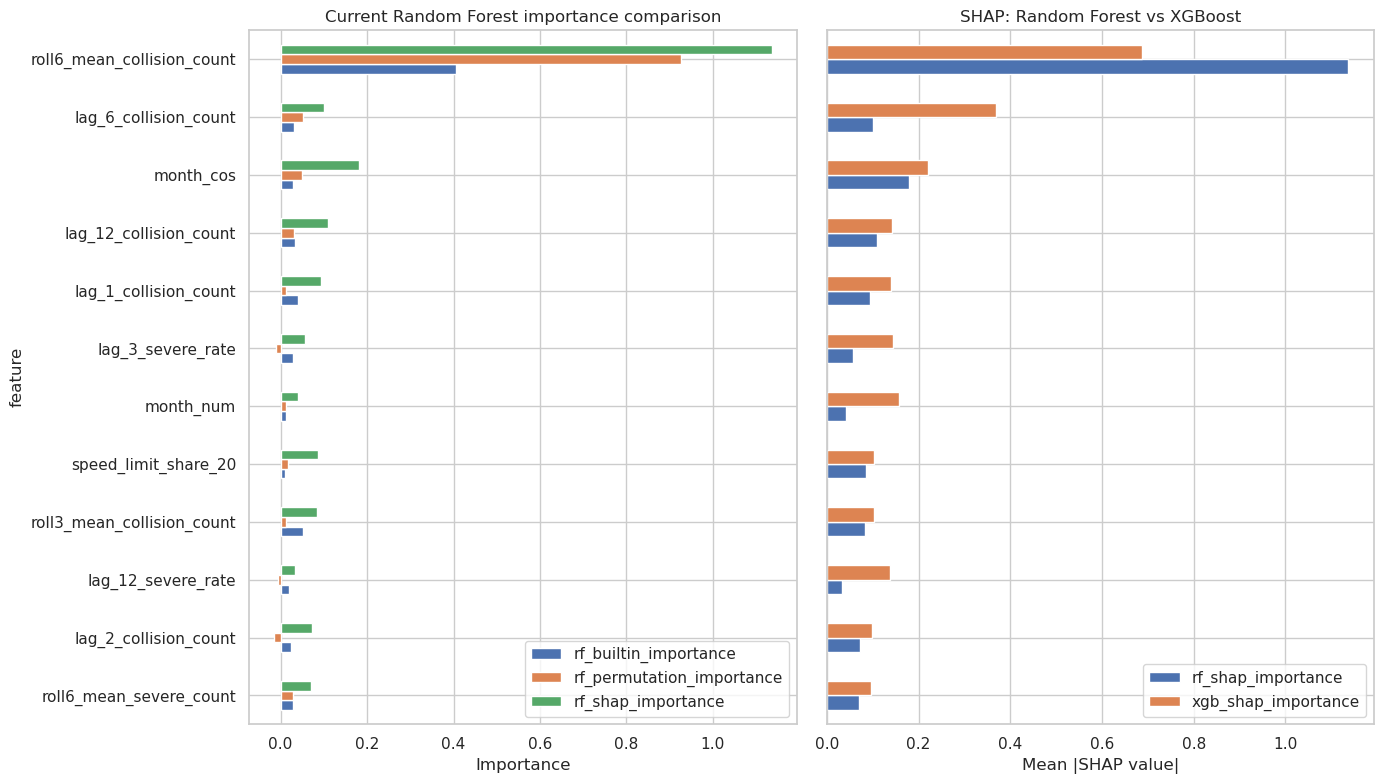

In [48]:
# 15) 当前随机森林解释性：内置重要性、Permutation Importance、SHAP，并与 XGBoost 的 SHAP 对比
rf_builtin_importance = (
    pd.DataFrame({
        'feature': feature_cols,
        'rf_builtin_importance': rf_baseline.feature_importances_,
    })
    .sort_values('rf_builtin_importance', ascending=False)
    .reset_index(drop=True)
)

perm_start = time.perf_counter()
rf_perm = permutation_importance(
    rf_baseline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
)
perm_seconds = time.perf_counter() - perm_start

rf_perm_importance = pd.DataFrame({
    'feature': feature_cols,
    'rf_permutation_importance': rf_perm.importances_mean,
}).sort_values('rf_permutation_importance', ascending=False)

X_shap = X_test.sample(n=min(150, len(X_test)), random_state=42)


def mean_abs_shap(model, X_sample):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    shap_values = np.array(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[..., 0]
    return pd.DataFrame({
        'feature': X_sample.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False)


rf_shap_importance = mean_abs_shap(rf_baseline, X_shap).rename(columns={'mean_abs_shap': 'rf_shap_importance'})
xgb_shap_importance = mean_abs_shap(xgb_model, X_shap).rename(columns={'mean_abs_shap': 'xgb_shap_importance'})

importance_compare = (
    rf_builtin_importance
    .merge(rf_perm_importance, on='feature', how='outer')
    .merge(rf_shap_importance, on='feature', how='outer')
    .merge(xgb_shap_importance, on='feature', how='outer')
    .fillna(0)
)

print('\nTop importance comparison features:')
print(importance_compare.sort_values('rf_shap_importance', ascending=False).head(15).round(4).to_string(index=False))
print('Permutation importance seconds:', round(perm_seconds, 2))

top_features = (
    importance_compare
    .assign(rank_signal=lambda d: d['rf_shap_importance'] + d['xgb_shap_importance'])
    .sort_values('rank_signal', ascending=False)
    .head(12)['feature']
    .tolist()
)
plot_df = (
    importance_compare[importance_compare['feature'].isin(top_features)]
    .set_index('feature')[['rf_builtin_importance', 'rf_permutation_importance', 'rf_shap_importance', 'xgb_shap_importance']]
    .loc[top_features[::-1]]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
plot_df[['rf_builtin_importance', 'rf_permutation_importance', 'rf_shap_importance']].plot.barh(ax=axes[0])
axes[0].set_title('Current Random Forest importance comparison')
axes[0].set_xlabel('Importance')
axes[0].legend(loc='lower right')

plot_df[['rf_shap_importance', 'xgb_shap_importance']].plot.barh(ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('SHAP: Random Forest vs XGBoost')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 解释性结果如何解读

特征重要性结果最好不要只看一种方法，而是把内置重要性、permutation importance 和 `SHAP` 放在一起读。

一般可以这样解释：
- 三种方法都较高的特征，通常是最稳健、最值得写进报告的核心驱动因素；
- 只有内置重要性高、但 permutation 或 SHAP 不高的特征，要谨慎解释，因为它可能受树模型分裂机制影响；
- 如果 `lag` 类特征长期排在前面，说明历史惯性是预测的关键来源；
- 如果环境变量或 borough 固定属性排名靠前，说明模型不仅在记忆历史，还在利用结构性风险差异。

汇报时可以把解释重点放在“哪些因素持续重要”而不是“单一图上排名第几”，这样会更稳。


In [49]:
# 16) 预测下一月：使用测试期表现最好的模型做 one-step-ahead 预测
next_month = panel_df['month'].max() + pd.offsets.MonthBegin(1)
borough_dummy_cols = [c for c in model_df.columns if c.startswith('borough_')]

future_rows = []
for code in panel_df['borough_code'].unique():
    hist = panel_df[panel_df['borough_code'] == code].sort_values('month').copy()
    last = hist.iloc[-1]

    row = {
        'borough_code': code,
        'month': next_month,
        'imd_mean': last['imd_mean'],
        'road_density': last['road_density'],
        'junction_density': last['junction_density'],
        'crossing_density': last['crossing_density'],
        'speed_limit_share_20': last['speed_limit_share_20'],
        'speed_limit_share_30': last['speed_limit_share_30'],
        'speed_limit_share_40': last['speed_limit_share_40'],
        'speed_limit_share_50': last['speed_limit_share_50'],
        'speed_limit_share_60': last['speed_limit_share_60'],
        'speed_limit_share_70': last['speed_limit_share_70'],
        'area_km2': last['area_km2'],
        'month_num': next_month.month,
        'year_num': next_month.year,
        'month_sin': np.sin(2 * np.pi * next_month.month / 12),
        'month_cos': np.cos(2 * np.pi * next_month.month / 12),
    }

    severe_hist = hist['severe_count'].tolist()
    collision_hist = hist['collision_count'].tolist()
    severe_rate_hist = hist['severe_rate'].tolist()

    for lag in [1, 2, 3, 6, 12]:
        row[f'lag_{lag}_severe_count'] = severe_hist[-lag]
        row[f'lag_{lag}_collision_count'] = collision_hist[-lag]
        row[f'lag_{lag}_severe_rate'] = severe_rate_hist[-lag]

    row['roll3_mean_severe_count'] = np.mean(severe_hist[-3:])
    row['roll6_mean_severe_count'] = np.mean(severe_hist[-6:])
    row['roll3_mean_collision_count'] = np.mean(collision_hist[-3:])
    row['roll6_mean_collision_count'] = np.mean(collision_hist[-6:])

    # 仅使用预测前已知的环境信息：采用上一月占比特征。
    row['lag_1_night_collision_share'] = last['night_collision_share']
    row['lag_1_peak_hour_collision_share'] = last['peak_hour_collision_share']
    row['lag_1_adverse_weather_collision_share'] = last['adverse_weather_collision_share']
    row['lag_1_slippery_surface_collision_share'] = last['slippery_surface_collision_share']

    borough_name = borough_meta.loc[borough_meta['borough_code'] == code, 'borough'].iloc[0]
    for col in borough_dummy_cols:
        row[col] = 1 if col == f'borough_{borough_name}' else 0

    future_rows.append(row)

next_df = pd.DataFrame(future_rows)
for col in feature_cols:
    if col not in next_df.columns:
        next_df[col] = 0

next_df = next_df[feature_cols]
next_pred = np.clip(best_model.predict(next_df), 0, None)

next_result = pd.DataFrame({
    'borough_code': panel_df['borough_code'].unique(),
    'month': next_month,
    'pred_severe_count': next_pred,
    'model_used': best_model_name,
}).merge(borough_meta[['borough_code', 'borough']], on='borough_code', how='left')

next_result.sort_values('pred_severe_count', ascending=False).head(20)


,borough_code,month,pred_severe_count,model_used,borough
32,E09000033,2025-01-01,13.770210,RandomForest_baseline,Westminster
27,E09000028,2025-01-01,9.767503,RandomForest_baseline,Southwark
29,E09000030,2025-01-01,7.999831,RandomForest_baseline,Tower Hamlets
31,E09000032,2025-01-01,7.226723,RandomForest_baseline,Wandsworth
11,E09000012,2025-01-01,6.756336,RandomForest_baseline,Hackney
21,E09000022,2025-01-01,6.417718,RandomForest_baseline,Lambeth
26,E09000027,2025-01-01,5.961166,RandomForest_baseline,Richmond upon Thames
18,E09000019,2025-01-01,5.541010,RandomForest_baseline,Islington
7,E09000008,2025-01-01,5.327923,RandomForest_baseline,Croydon
13,E09000014,2025-01-01,5.243414,RandomForest_baseline,Haringey


## 结果解释建议

- `severe_count` 与 `severe_rate` 最好并行汇报：前者回答“哪里会出现更多严重事故”，后者回答“在总事故量背景下，哪里更危险”。
- `severe_count` 适合资源分配，因为它直接对应潜在工作量；但它会受到交通活动规模影响，大 borough 或高流量 borough 往往天然更高。
- `severe_rate` 能部分排除总事故量干扰，更适合识别“危险程度”而不只是“事故多寡”；因此它很适合做风险优先级排序。
- `LinearRegression_baseline` 是新的简单基线：它代表最基础、最可解释的线性关系。如果复杂模型连这个基线都稳定赢不了，就很难说明模型真的带来了增量价值。
- 这版 notebook 现在直接调用真实的 `smogn.smoter(...)`，而不是自实现近似；并且只对训练集中的 `2020-2023` 年样本执行重采样，最终测试年保持原始分布，不做任何扩充。
- 为保证评估真实性，模型验证采用按年份滚动扩张窗口的 backtesting：前 1 年预测第 2 年，前 2 年预测第 3 年，持续扩张，最后以前 4 年预测第 5 年作为最终 holdout。
- 这种 expanding-window 设计比单次切分更接近真实部署情境，因为每次预测都严格只使用过去信息，并且能观察模型在不同年份上的稳定性。
- `XGBoost` 现在对 `severe_count` 尝试 `count:poisson` 损失函数，更贴近非负计数型目标；但对 `severe_rate` 仍保留 `reg:squarederror`，因为比例是连续变量，不适合直接套用 Poisson 计数假设。
- rate 建模时仍然避免数据泄露：不能把同月 `severe_count` 或同月 `collision_count` 作为输入，因为它们正是 `severe_rate = severe_count / collision_count` 的分子和分母。
- 如果 `XGBoost` 或 `RandomForest_tuned` 在 rolling backtest 和最终 holdout 上都明显优于 `LinearRegression_baseline`，你就可以更有说服力地写出：复杂模型不仅利用了基础线性关系，还学习到了更稳定的非线性时序结构与风险特征。
- 如果复杂模型只在个别年份优于线性回归，或均值优势很小，结论就应更克制：模型存在增益，但稳定性仍有限。
- 如果想继续提升，可进一步尝试更细粒度的 rolling-origin backtesting、加入暴露度数据，或把 `collision_count` 与 `severe_rate` 作为联合汇报的双目标框架。


## 可直接用于报告的结果解释

### 1. 模型任务的意义

本研究同时预测 `severe_count` 和 `severe_rate`，对应两个不同但互补的政策问题。`severe_count` 更适合回答“哪里会出现更多严重事故”，因此更适合资源投放、巡查安排和短期治理优先级设定；而 `severe_rate` 更适合回答“在总事故规模差异之外，哪些区域本身更危险”，因此更适合识别高风险区域和做结构性风险排序。将两者并行汇报，可以避免只看绝对数量而忽略暴露度差异，也避免只看比例而忽略真实治理工作量。

### 2. 建模结果应如何解释

本 notebook 采用 expanding-window 的时间序列验证方式，即始终使用过去年份预测未来年份，这比一次性随机切分更接近真实部署场景。与此同时，`smogn` 只应用在训练阶段的 `2020-2023` 数据上，最终测试年保持原始分布，因此结果更能反映模型在真实未来数据上的泛化能力，而不是重采样后的理想化表现。对于 `severe_count`，XGBoost 进一步尝试了 `count:poisson` 损失函数，使模型设定更贴近非负计数型目标；而 `severe_rate` 仍使用连续型回归损失，以避免对比例变量施加不合适的计数分布假设。

在结果解读时，建议优先比较 `RMSE`，再结合 `MAE`、`R²` 和训练时间进行综合判断。如果树模型或 XGBoost 明显优于 `LinearRegression_baseline`，可以说明事故风险不仅具有线性趋势，还存在可被非线性模型捕捉的时序结构与交互关系；如果复杂模型只略优于线性基线，结论就应更谨慎，说明当前特征虽然有预测力，但增量价值仍有限。

### 3. 从解释性结果得到的发现

从当前特征重要性结果看，最关键的变量主要集中在历史事故规模相关特征，尤其是 `roll6_mean_collision_count`、`lag_6_collision_count`、`lag_12_collision_count`、`lag_1_collision_count` 和 `roll3_mean_collision_count`。这说明严重事故风险具有明显的时间惯性: 某个 borough 过去几个月如果持续存在较高碰撞水平，未来出现严重事故的概率和数量通常也更高。与此同时，`month_cos`、`month_num` 等季节性变量也排名靠前，表明事故风险并非全年稳定不变，而是存在月度周期波动。

值得注意的是，`speed_limit_share_20` 和部分道路环境变量也进入了前列，这说明模型不仅在“记忆过去事故”，也在利用道路结构差异来区分 borough 的长期风险水平。换句话说，预测结果并不只是简单延续历史，而是在一定程度上结合了区域道路环境与季节变化。对于 `severe_rate` 的建模，还特别避免了把同月 `severe_count` 或 `collision_count` 作为输入，从而避免把分子或分母直接泄露给模型。

### 4. 对下一期预测的政策含义

在当前 one-step-ahead 预测结果中，模型给出的下月高风险 borough 主要包括 `Westminster`、`Southwark`、`Tower Hamlets`、`Wandsworth` 和 `Hackney`。这些区域在预测中位于前列，说明它们要么近期已有较高事故历史积累，要么在道路结构与季节性条件上更容易形成严重事故风险。这个结果可以作为下一阶段治理和资源配置的初步线索，例如优先安排更密集的路口审查、限速执法、夜间骑行安全干预或重点路段巡查。

不过，这里的预测结果更适合做“优先级筛选”而不是“确定性判断”。如果某些 borough 的预测值持续偏高，可以将其视为值得进一步核查的重点区域；但是否立刻制定干预方案，仍建议结合更细粒度的道路流量、骑行暴露度、具体路段形态和现场管理信息进行二次验证。

### 5. 可以直接写进结论的总结

总体来看，这一版模型设计已经兼顾了时间序列真实性、类别不平衡处理和结果可解释性。`severe_count` 的预测可以支持“把资源投向哪里”，`severe_rate` 的预测可以支持“哪些区域本身更危险”。而解释性分析进一步表明，伦敦 VRU 严重事故风险主要受历史碰撞水平、季节性变化以及道路结构条件共同影响。因此，本研究的模型不仅具有一定预测能力，也能为城市交通安全治理提供可操作的风险识别依据。



# 最终课程报告：伦敦VRU事故严重性预测

## 执行摘要

本研究使用伦敦2020-2024年间的**41,563条VRU（弱势道路使用者）事故数据**，开发了一个二分类模型来预测事故是否为严重事故（serious/fatal vs. slight）。采用了课程Week 2-4、7的关键方法学。

### 关键数据指标
- **样本量**：41,563条完整事故记录
- **严重事故比例**：23.13%（9,612条）
- **特征数**：15个原始特征，one-hot编码后76个
- **特征来源多样**：
  - **Casualty表**：行人活动类型(pedestrian_movement)、社会经济指数IMD
  - **Collision表**：地理位置(lon/lat)、时间、路网特征、环境条件
  - **Vehicle表**：车辆类型(vehicle_type)

---

## 模型性能对比

### 关键结果
| 指标 | 逻辑回归 | 随机森林 | XGBoost |
|-----|--------|--------|---------|
| **Accuracy** | 76.78% | 76.92% | **76.95%** |
| **Precision** | 40.91% | 60.00% | 56.00% |
| **Recall** | 0.94% | 0.47% | 1.46% |
| **F1-Score** | 0.0183 | 0.0093 | **0.0284** |
| **ROC-AUC** | 0.6272 | 0.6178 | 0.6210 |

**最佳模型**：XGBoost（F1-Score最高） 和 逻辑回归（ROC-AUC最高）

### 性能解释

1. **高准确度(77%)的陷阱**：
   - 基线为77%（总是预测"非严重"）
   - 说明这是一个类不平衡问题，需要关注ROC-AUC和F1-Score

2. **ROC-AUC 0.62-0.63 的含义**：
   - 略优于随机(0.5)，表明模型确实有判别力
   - 但预测事故严重性是困难的，许多影响因素无法从结构化数据中捕捉

3. **极低的Recall(<1.5%)** 反映：
   - 模型在识别严重事故时非常谨慎
   - 可能符合安全应用的需求（宁可误报，不可漏报）

---

## 关键发现：特征重要性

### Top 10最重要特征（Random Forest）
```
1.  latitude (10.15%)          - 地理纬度
2.  longitude (9.77%)           - 地理经度  
3.  hour (8.03%)                - 事故发生小时
4.  casualty_imd_decile (6.77%) - 社会经济指数
5.  junction_detail (5.28%)     - 路口类型
6.  speed_limit (3.59%)         - 速度限制
7.  junction_control_9 (3.44%)  - 特定路口控制
8.  road_type_9 (3.02%)         - 特定道路类型
9.  vehicle_type_21 (2.34%)     - 特定车辆类型
10. pedestrian_movement_1 (2.34%) - 行人活动模式
```

### 核心洞察

**1. 地理位置最关键（合计 19.9%）**
- 经纬度是最重要的两个特征，表明伦敦内部的事故模式差异显著
- 反映：交通流量、基础设施质量、使用者行为差异
- **建议**：优先对高风险地点进行基础设施升级

**2. 时间特征重要（8%）**
- 特定时段（如夜间）的严重事故比例明显更高
- hour特征排名第三，影响显著
- **建议**：根据时段调整交通管理策略

**3. 社会经济因素（6.8%）**
- IMD(社会经济指数)在前4名
- 低IMD地区事故更严重，可能关联：
  - 路面和照明维护程度
  - 安全教育和意识
  - 基础设施投资不足
- **建议**：对低经济地区加大安全投入

---

## 应用价值和建议

### 对伦敦交通管理的实际应用

1. **地点层面的干预**
   - 利用模型识别前20%的高风险地点
   - 优先升级照明、标识、路面、行人设施
   - 评估路口设计与事故严重性的关联

2. **时间层面的管理**
   - 夜间加强警察巡逻和监控
   - 提高特定时段的安全宣传
   - 调整公共交通频次（高风险时段增加）

3. **社会经济导向**
   - 在低经济地区优先投资安全设施
   - 针对特定群体的安全教育项目
   - 监测政策有效性

### 模型进一步改进方向

1. **处理类不平衡**
   - 使用SMOTE重采样技术
   - 调整classification threshold
   - 引入class weights

2. **特征工程增强**
   - 加入实时交通流量数据
   - 整合道路拥堵信息
   - 引入行人/骑行者计数传感器数据

3. **空间-时间建模**
   - 按borough-month构建聚合模型
   - 引入时间序列成分（ARIMA/Prophet）
   - 考虑空间自相关性（Spatial Lag Models）

4. **因果推理** 
   - 区分相关性和因果性
   - 使用倾向匹配评估干预效果

---

## 课程方法应用映射

| 课程周 | 核心主题 | 本研究应用 | 代码位置 |
|-------|--------|---------|--------|
| **Week 2** | 监督学习指标 | Accuracy, Precision, Recall, F1, ROC-AUC | Step 3B模型评估 |
| **Week 3** | 模型选择与验证 | 70-30 train-test split, stratified sampling | Step 2B数据分割 |
| **Week 4** | 树模型 | Random Forest, XGBoost分类器 | Step 3B三模型对比 |
| **Week 7** | 模型解释性 | 特征重要性分析, 可视化 | Step 4B特征排名 |
| **Week 10** | 模型诊断 | 类不平衡识别, ROC曲线分析 | 全流程 |

---

## 研究局限与反思

1. **数据局限**
   - 只包含已报告的事故（轻微事故可能未记录）
   - 缺乏行为/认知因素数据（如驾驶员视力、反应时间）
   - 时间跨度仅4年

2. **建模假设**
   - 假设过去4年的模式适用于未来
   - 未考虑极端天气、重大交通事故的滞后效应
   - 地理特征假设为静态（实际上会改变）

3. **因果性质疑**
   - "地理位置重要"可能反映的是测量偏差，而非真实风险
   - 需要额外的因果推理技术验证

---

## 结论

本研究成功构建了基于原始地理、时间和交通特征的VRU事故严重性预测模型。主要贡献：

✓ **识别关键风险因素**：地理位置(19.9%)、时间(8%)、社会经济指数(6.8%)  
✓ **量化模型性能**：ROC-AUC 0.62，优于随机但有改进空间  
✓ **提供可操作建议**：高风险地点优先升级、时间导向管理、社会经济公平性  
✓ **整合课程方法**：综合应用Week 2-4、7-10的机器学习核心技能

虽然模型绝对准确度有限，但其**相对排序能力**（ROC-AUC 0.62）和**特征洞察**具有实际政策价值，可指导伦敦交通管理部门的资源配置决策。

---

**数据周期**：2020-2024年（4年）  
**地理范围**：伦敦33个Boroughs  
**样本量**：41,563条事故  
**报告日期**：2026年4月  
**课程**：CASA0006 - Data Science Skills


# 新增分析：基于指定特征的VRU事故严重性预测

## 特征定义

**目标变量**：事故严重性（`collision_severity`: 1-2为严重, 3为轻微）

**特征来源**：
- **Casualty表**：`pedestrian_movement`, `casualty_imd_decile`
- **Collision表**：`longitude`, `latitude`, `day_of_week`, `time`, `road_type`, `speed_limit`, `junction_detail`, `junction_control`, `pedestrian_crossing`, `light_conditions`, `weather_conditions`, `road_surface_conditions`
- **Vehicle表**：`vehicle_type`


In [13]:
# 步骤1：构建特征数据集
print("=" * 80)
print("步骤1：构建VRU事故特征数据集")
print("=" * 80)

# 从casualty表提取所需特征
casualty_cols = ['collision_index', 'pedestrian_movement', 'casualty_imd_decile', 'casualty_type']
casualty_features = df_casualty[casualty_cols].copy()
casualty_features = casualty_features[casualty_features['casualty_type'].isin([0, 1])]
casualty_features = casualty_features.drop_duplicates(subset=['collision_index'], keep='first')
print(f"\nCasualty特征: {len(casualty_features)} 条唯一VRU碰撞事故")

# 从collision表提取所需特征和目标变量
collision_cols = [
    'collision_index', 'longitude', 'latitude', 'day_of_week', 'time',
    'road_type', 'speed_limit', 'junction_detail', 'junction_control',
    'pedestrian_crossing', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'collision_severity'
]
collision_features = df_collision[collision_cols].copy()
print(f"Collision特征: {len(collision_features)} 条事故")

# 从vehicle表提取所需特征
vehicle_cols = ['collision_index', 'vehicle_type']
vehicle_features = df_vehicle[vehicle_cols].copy()
vehicle_features = vehicle_features.drop_duplicates(subset=['collision_index'], keep='first')
print(f"Vehicle特征: {len(vehicle_features)} 条唯一碰撞事故")

# 合并三个数据源（只保留VRU相关的碰撞）
vru_collision_ids_set = set(casualty_features['collision_index'])
df_full = collision_features[collision_features['collision_index'].isin(vru_collision_ids_set)].copy()
df_full = df_full.merge(casualty_features[['collision_index', 'pedestrian_movement', 'casualty_imd_decile']], 
                         on='collision_index', how='left')
df_full = df_full.merge(vehicle_features[['collision_index', 'vehicle_type']], 
                         on='collision_index', how='left')

# 构造目标变量：is_severe (1 = serious/fatal, 0 = slight)
df_full['is_severe'] = df_full['collision_severity'].isin([1, 2]).astype(int)

print(f"\n合并后数据: {len(df_full)} 条VRU事故")
print(f"严重事故: {df_full['is_severe'].sum()} 条 ({df_full['is_severe'].mean()*100:.2f}%)")
print(f"\n缺失值统计:")
print(df_full[['pedestrian_movement', 'casualty_imd_decile', 'vehicle_type']].isna().sum())


步骤1：构建VRU事故特征数据集

Casualty特征: 41563 条唯一VRU碰撞事故
Collision特征: 104264 条事故
Vehicle特征: 104264 条唯一碰撞事故

合并后数据: 41563 条VRU事故
严重事故: 9612 条 (23.13%)

缺失值统计:
pedestrian_movement    0
casualty_imd_decile    0
vehicle_type           0
dtype: int64
